In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
aadigupta1601_f1_strategy_dataset_pit_stop_prediction_path = kagglehub.dataset_download('aadigupta1601/f1-strategy-dataset-pit-stop-prediction')

print('Data source import complete.')


Using Colab cache for faster access to the 'f1-strategy-dataset-pit-stop-prediction' dataset.
Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv


In [ ]:
df = pd.read_csv("/kaggle/input/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv")

In [ ]:
df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  object 
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife 

In [ ]:
df.select_dtypes(include='object').columns

Index(['Driver', 'Compound', 'Race'], dtype='object')

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Re-initialize LabelEncoder just in case, though it's already done
le = LabelEncoder()

# Identify object columns that still exist in the DataFrame 'df'
# This is crucial because 'Driver' might have been removed or transformed
object_cols = df.select_dtypes(include='object').columns

# Apply Label Encoding only to the object columns that are actually present
for col in object_cols:
    df[col] = le.fit_transform(df[col])


In [ ]:
y = df["PitNextLap"]
X = df.drop(columns=["PitNextLap"])

In [ ]:
X.dtypes

,0
Driver,int64
LapNumber,int64
Compound,int64
Stint,int64
TyreLife,float64
Position,int64
LapTime (s),float64
Race,int64
Year,int64
LapTime_Delta,float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20
)

Epoch 1/20
2218/2218 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8102 - loss: 0.4194 - val_accuracy: 0.8319 - val_loss: 0.3766
Epoch 2/20
2218/2218 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8402 - loss: 0.3545 - val_accuracy: 0.8353 - val_loss: 0.3593
Epoch 3/20
2218/2218 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8514 - loss: 0.3293 - val_accuracy: 0.8497 - val_loss: 0.3372
Epoch 4/20
2218/2218 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8610 - loss: 0.3108 - val_accuracy: 0.8595 - val_loss: 0.3124
Epoch 5/20
2218/2218 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8658 - loss: 0.2991 - val_accuracy: 0.8565 - val_loss: 0.3106
Epoch 6/20
2218/2218 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8720 - loss: 0.2879 - val_accuracy: 0.8589 - val_loss: 0.3090
Epoch 7/20
2218/2218 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8774 - loss: 0.2796 - val_accuracy: 0.8725 - val_loss: 0.2858
Epoch 8/20
2218/2218 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8799 - loss: 0.2712 - 

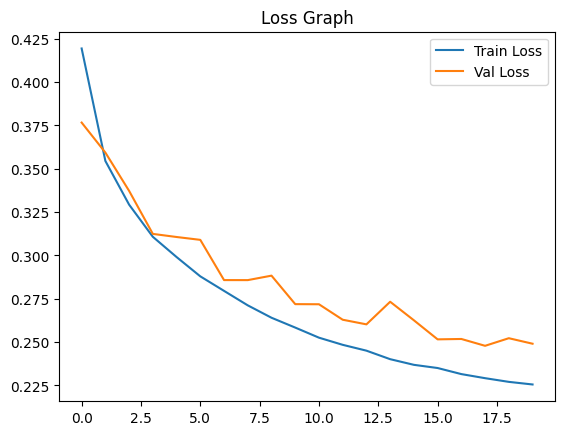

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.title("Loss Graph")
plt.legend()
plt.show()

In [16]:
model.save("f1-strategy.keras")

In [18]:
from google.colab import files
files.download("f1-strategy.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>